# Boston House Price Prediction

## Machine Learning Engineer Internship — Beginner Task

**Objective:** Build a regression model to predict Boston house prices using the provided housing dataset.

The internship task asks for data preprocessing, model selection, training, and evaluation.

### Workflow
1. Import libraries
2. Load and inspect the dataset
3. Handle missing values
4. Explore the data
5. Split data into training and testing sets
6. Train multiple regression models
7. Evaluate models using MAE, RMSE, and R²
8. Select the best model
9. Generate sample predictions
10. Analyze feature importance
11. Draw conclusions

In [24]:
# 1. Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
print("Libraries imported successfully.")

Libraries imported successfully.


In [25]:
# 2. Load the dataset

df = pd.read_csv("/HousingData.csv")

print("Dataset shape:", df.shape)
print("\nFirst five rows:")
print(df.head())

Dataset shape: (506, 14)

First five rows:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  


In [26]:
# 3. Inspect the dataset

print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Column names:
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

Data types:
CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

Missing values:
CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

Duplicate rows: 0


## Dataset understanding

The target variable is **MEDV**, representing the median value of owner-occupied homes.

The dataset contains 506 rows and 14 columns. Several input columns contain missing values, so they must be handled before model training.

In [27]:
# 4. Statistical summary

print(df.describe().round(2).to_string())

         CRIM      ZN   INDUS    CHAS     NOX      RM     AGE     DIS     RAD     TAX  PTRATIO       B   LSTAT    MEDV
count  486.00  486.00  486.00  486.00  506.00  506.00  486.00  506.00  506.00  506.00   506.00  506.00  486.00  506.00
mean     3.61   11.21   11.08    0.07    0.55    6.28   68.52    3.80    9.55  408.24    18.46  356.67   12.72   22.53
std      8.72   23.39    6.84    0.26    0.12    0.70   28.00    2.11    8.71  168.54     2.16   91.29    7.16    9.20
min      0.01    0.00    0.46    0.00    0.38    3.56    2.90    1.13    1.00  187.00    12.60    0.32    1.73    5.00
25%      0.08    0.00    5.19    0.00    0.45    5.89   45.18    2.10    4.00  279.00    17.40  375.38    7.12   17.02
50%      0.25    0.00    9.69    0.00    0.54    6.21   76.80    3.21    5.00  330.00    19.05  391.44   11.43   21.20
75%      3.56   12.50   18.10    0.00    0.62    6.62   93.98    5.19   24.00  666.00    20.20  396.22   16.96   25.00
max     88.98  100.00   27.74    1.00    0.87   

In [28]:
# 5. Separate features and target

X = df.drop(columns=["MEDV"])
y = df["MEDV"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (506, 13)
Target shape: (506,)


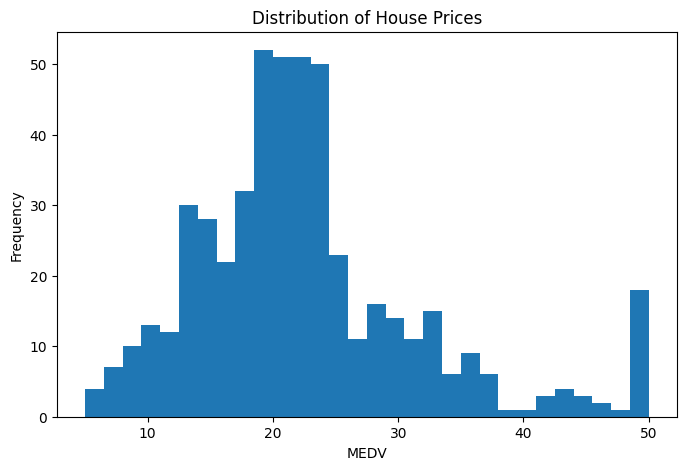

In [29]:
# 6. Explore the target variable

plt.figure(figsize=(8, 5))
plt.hist(y, bins=30)
plt.xlabel("MEDV")
plt.ylabel("Frequency")
plt.title("Distribution of House Prices")
plt.show()

In [30]:
# 7. Correlation with the target

correlations = df.corr(numeric_only=True)["MEDV"].sort_values(ascending=False)
print(correlations.round(3).to_string())

MEDV       1.000
RM         0.695
ZN         0.373
B          0.333
DIS        0.250
CHAS       0.181
RAD       -0.382
CRIM      -0.391
AGE       -0.395
NOX       -0.427
TAX       -0.469
INDUS     -0.482
PTRATIO   -0.508
LSTAT     -0.736


In [31]:
# 8. Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 404
Testing samples: 102


## Data preprocessing

Missing numeric values are handled using **median imputation**. Median imputation is less sensitive to extreme values than mean imputation.

For models that benefit from comparable feature scales, standardization is included in the pipeline.

In [32]:
# 9. Define models

models = {
    "Linear Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(
            random_state=42
        ))
    ])
}

print("Models prepared:", ", ".join(models.keys()))

Models prepared: Linear Regression, Ridge Regression, Random Forest, Gradient Boosting


In [33]:
# 10. Train and evaluate all models

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append([name, mae, rmse, r2])
    trained_models[name] = model

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
).sort_values("R2 Score", ascending=False)

print(results_df.round(4).to_string(index=False))

            Model    MAE   RMSE  R2 Score
Gradient Boosting 1.9187 2.7024    0.9004
    Random Forest 2.0743 3.0168    0.8759
Linear Regression 3.1476 4.9983    0.6593
 Ridge Regression 3.1446 4.9987    0.6593


## Evaluation metrics

- **MAE (Mean Absolute Error):** average absolute difference between actual and predicted prices. Lower is better.
- **RMSE (Root Mean Squared Error):** penalizes larger errors more strongly. Lower is better.
- **R² Score:** indicates how much variation in the target is explained by the model. Higher is better.

In [34]:
# 11. Select the best model

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)
print("Best R² score:", round(results_df.iloc[0]["R2 Score"], 4))

Best model: Gradient Boosting
Best R² score: 0.9004


 Actual MEDV  Predicted MEDV
        23.6           23.29
        32.4           31.98
        13.6           16.91
        22.8           23.87
        16.1           17.58
        20.0           22.18
        17.8           18.25
        14.0           14.62
        19.6           20.30
        16.8           20.62


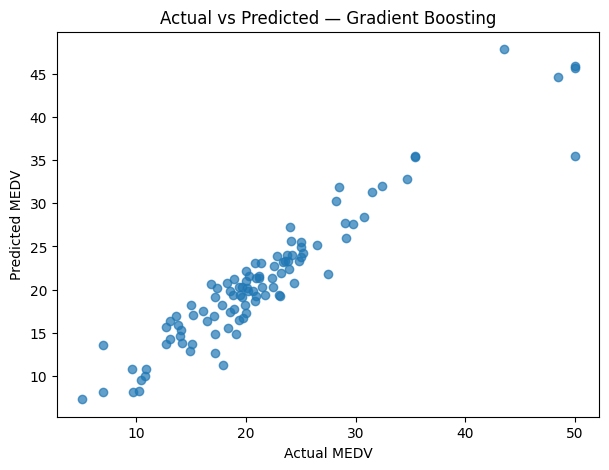

In [35]:
# 12. Actual vs predicted values

best_predictions = best_model.predict(X_test)

comparison = pd.DataFrame({
    "Actual MEDV": y_test.values,
    "Predicted MEDV": best_predictions
})

print(comparison.head(10).round(2).to_string(index=False))

plt.figure(figsize=(7, 5))
plt.scatter(y_test, best_predictions, alpha=0.7)
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.show()

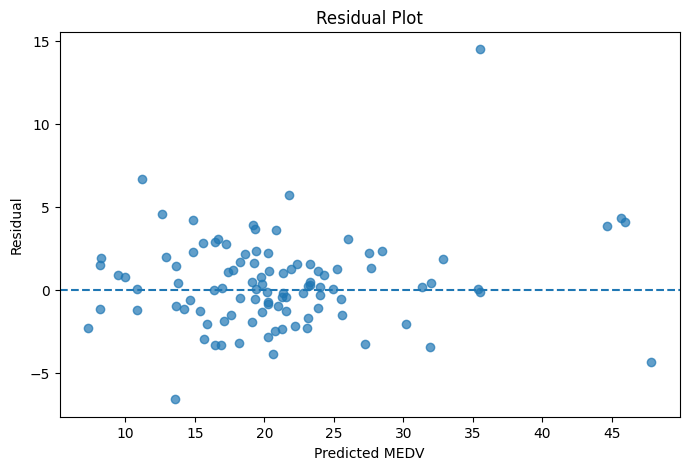

In [36]:
# 13. Residual analysis

residuals = y_test - best_predictions

plt.figure(figsize=(8, 5))
plt.scatter(best_predictions, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted MEDV")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

RM         0.5014
LSTAT      0.2785
DIS        0.0828
CRIM       0.0354
NOX        0.0344
PTRATIO    0.0311
TAX        0.0125
AGE        0.0097
B          0.0088
INDUS      0.0023
RAD        0.0016
CHAS       0.0011
ZN         0.0003


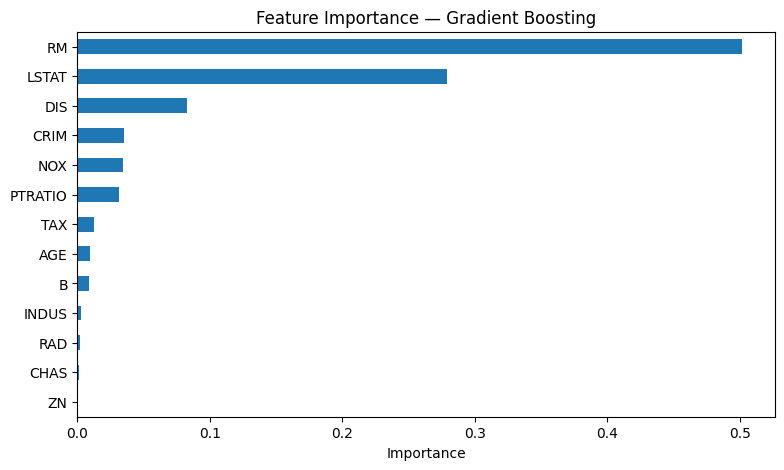

In [37]:
# 14. Feature importance for tree-based best models

if best_model_name in ["Random Forest", "Gradient Boosting"]:
    estimator = best_model.named_steps["model"]
    importances = pd.Series(
        estimator.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    print(importances.round(4).to_string())

    plt.figure(figsize=(9, 5))
    importances.sort_values().plot(kind="barh")
    plt.xlabel("Importance")
    plt.title(f"Feature Importance — {best_model_name}")
    plt.show()
else:
    print("Feature importance visualization is not used for the selected linear model.")

In [38]:
# 15. Example predictions

sample = X_test.head(5)
sample_predictions = best_model.predict(sample)

prediction_table = sample.copy()
prediction_table["Predicted MEDV"] = sample_predictions

print(prediction_table.round(2).to_string())

     CRIM    ZN  INDUS  CHAS   NOX    RM   AGE   DIS  RAD  TAX  PTRATIO       B  LSTAT  Predicted MEDV
173  0.09   0.0    NaN   0.0  0.51  6.42   NaN  2.65    5  296     16.6  395.50   9.04           23.29
274  0.06  40.0   6.41   1.0  0.45  6.76  32.9  4.08    4  254     17.6  396.90   3.53           31.98
491  0.11   0.0  27.74   0.0  0.61  5.98  98.8  1.87    4  711     20.1  390.11  18.07           16.91
72   0.09   0.0  10.81   0.0  0.41  6.06   7.8  5.29    4  305     19.2  390.91   5.52           23.87
452  5.09   0.0  18.10   0.0  0.71  6.30  91.8  2.37   24  666     20.2  385.09  17.27           17.58


## Conclusion

The project successfully implements a complete house-price regression workflow.

The dataset was inspected and missing input values were handled using median imputation. Four regression approaches were compared: Linear Regression, Ridge Regression, Random Forest, and Gradient Boosting.

For this dataset and the fixed train-test split used in this notebook, **Gradient Boosting achieved the highest R² score among the tested models**, making it the selected model.

The final model can be used to estimate house prices from the available housing features. Model performance should be interpreted in the context of this dataset and split; it does not guarantee performance on new real-world housing markets.